# Data Quality Assessment & Cleaning — NewCustomerList

**Table:** `NewCustomerList` — 1,000 prospects the business has not sold to yet.

This is the table the project is ultimately for. The 4,000 existing customers are used to
learn what a valuable customer looks like; these 1,000 are who the marketing budget would
actually be spent on.

It has no `customer_id` and no transactions — by definition, since nobody here has bought
anything. So it cannot be scored with RFM directly, and it carries five unnamed columns plus
a pre-existing `Rank` and `Value` whose provenance needs checking before anything is trusted.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_excel('Raw_data.xlsx', sheet_name='NewCustomerList')
print(f'{df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

1,000 rows x 23 columns


,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,owns_car,tenure,address,postcode,state,country,property_valuation,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Rank,Value
0,Chickie,Brister,Male,86,1957-07-12,General Manager,Manufacturing,Mass Customer,N,Yes,14,45 Shopko Center,4500,QLD,Australia,6,0.81,1.0125,1.265625,1.075781,1,1,1.718750
1,Morly,Genery,Male,69,1970-03-22,Structural Engineer,Property,Mass Customer,N,No,16,14 Mccormick Park,2113,NSW,Australia,11,0.75,0.7500,0.937500,0.796875,1,1,1.718750
2,Ardelis,Forrester,Female,10,1974-08-28 00:00:00,Senior Cost Accountant,Financial Services,Affluent Customer,N,No,10,5 Colorado Crossing,3505,VIC,Australia,5,0.71,0.7100,0.710000,0.710000,1,1,1.718750
3,Lucine,Stutt,Female,64,1979-01-28,Account Representative III,Manufacturing,Affluent Customer,N,Yes,5,207 Annamark Plaza,4814,QLD,Australia,1,0.50,0.6250,0.625000,0.625000,4,4,1.703125
4,Melinda,Hadlee,Female,34,1965-09-21,Financial Analyst,Financial Services,Affluent Customer,N,No,19,115 Montana Place,2093,NSW,Australia,9,0.99,0.9900,1.237500,1.237500,4,4,1.703125


## 1. First look

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   first_name                           1000 non-null   object 
 1   last_name                            971 non-null    object 
 2   gender                               1000 non-null   object 
 3   past_3_years_bike_related_purchases  1000 non-null   int64  
 4   DOB                                  983 non-null    object 
 5   job_title                            894 non-null    object 
 6   job_industry_category                835 non-null    object 
 7   wealth_segment                       1000 non-null   object 
 8   deceased_indicator                   1000 non-null   object 
 9   owns_car                             1000 non-null   object 
 10  tenure                               1000 non-null   int64  
 11  address                        

In [3]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pd.DataFrame({'missing': missing, 'pct': (100 * missing / len(df)).round(2)})

,missing,pct
job_industry_category,165,16.5
job_title,106,10.6
last_name,29,2.9
DOB,17,1.7


## 2. Issue: five unnamed columns

Columns 16 to 20 have no headers, which usually means they were working cells left in the
sheet. Before dropping them, check what they contain — an unnamed column with real meaning
would be worth keeping and naming.

In [4]:
unnamed = [c for c in df.columns if str(c).startswith('Unnamed')]
df[unnamed + ['Rank', 'Value']].head(8)

,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Rank,Value
0,0.81,1.0125,1.265625,1.075781,1,1,1.718750
1,0.75,0.7500,0.937500,0.796875,1,1,1.718750
2,0.71,0.7100,0.710000,0.710000,1,1,1.718750
3,0.50,0.6250,0.625000,0.625000,4,4,1.703125
4,0.99,0.9900,1.237500,1.237500,4,4,1.703125
5,0.70,0.8750,0.875000,0.875000,6,6,1.671875
6,0.67,0.6700,0.670000,0.569500,6,6,1.671875
7,0.73,0.9125,0.912500,0.775625,8,8,1.656250


In [5]:
for c in unnamed:
    print(f'{c}: {df[c].nunique()} distinct, range {df[c].min()} to {df[c].max()}')

Unnamed: 16: 71 distinct, range 0.4 to 1.1
Unnamed: 17: 132 distinct, range 0.4 to 1.375
Unnamed: 18: 187 distinct, range 0.4 to 1.71875
Unnamed: 19: 317 distinct, range 0.34 to 1.71875
Unnamed: 20: 324 distinct, range 1 to 1000


These are intermediate arithmetic — a value being multiplied down a chain, ending in the
`Value` column. They are the workings of somebody's scoring formula, left in the export.

**Action:** drop all five. They carry no customer attribute and no documented meaning.

In [6]:
df = df.drop(columns=unnamed)
print(f'dropped {len(unnamed)} columns. {df.shape[1]} remain')

dropped 5 columns. 18 remain


## 3. Check: what are `Rank` and `Value`?

These arrived with the file rather than being derived here, so they need to be understood
before they are used or trusted.

In [7]:
print('Rank :', df['Rank'].min(), 'to', df['Rank'].max(),
      f"({df['Rank'].nunique()} distinct)")
print('Value:', round(df['Value'].min(), 4), 'to', round(df['Value'].max(), 4),
      f"({df['Value'].nunique()} distinct)")
print()
print('rows sharing a Rank:')
print(df['Rank'].value_counts().head(5).to_string())

Rank : 1 to 1000 (324 distinct)
Value: 0.34 to 1.7188 (324 distinct)

rows sharing a Rank:
Rank
760    13
259    12
455     9
133     9
386     9


`Rank` is not unique — many prospects share a rank, because it is a dense ranking of `Value`,
and `Value` itself is the output of the undocumented formula whose workings we just dropped.

**Action: keep both, use neither as ground truth.** They are somebody else's scoring, with no
stated method behind them. This project builds its own view of prospect value from the RFM
model, and `Value` is kept only so the two can be compared at the end.

Treating an unexplained score as the answer is how an analysis inherits someone else's
assumptions without noticing.

## 4. Issue: gender is not standardised

The same problem as the existing-customer table, so it gets the same treatment — consistency
between the two matters, because they are compared side by side in the EDA.

In [8]:
df['gender'].value_counts(dropna=False)

gender
Female    513
Male      470
U          17
Name: count, dtype: int64

In [9]:
gender_map = {'F': 'Female', 'Femal': 'Female', 'Female': 'Female',
              'M': 'Male', 'Male': 'Male', 'U': 'Unknown'}
df['gender'] = df['gender'].map(gender_map)
df['gender'].value_counts(dropna=False)

gender
Female     513
Male       470
Unknown     17
Name: count, dtype: int64

## 5. Derive Age and Age Group

Measured as at the same fixed date used for existing customers — **2017-12-31**. Using two
different reference dates would make the new-vs-existing age comparison meaningless.

In [10]:
AS_AT = pd.Timestamp('2017-12-31')

df['DOB'] = pd.to_datetime(df['DOB'], errors='coerce')
df['Age'] = ((AS_AT - df['DOB']).dt.days / 365.25).round().astype('Int64')

bins   = [0, 19, 29, 39, 49, 59, 69, 79, 200]
labels = ['Under 20', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

print(f"age range: {df['Age'].min()} to {df['Age'].max()}")
print(f"missing DOB: {df['Age'].isna().sum()}")
df[['Age']].describe().T

age range: 16 to 80
missing DOB: 17


,count,mean,std,min,25%,50%,75%,max
Age,983.0,46.677518,17.056954,16.0,35.0,46.0,60.0,80.0


No 174-year-old here — the age range is plausible, so unlike the existing-customer table
there is no outlier to remove.

## 6. Missing values

In [11]:
df[['last_name', 'DOB', 'job_title', 'job_industry_category']].isna().sum()

last_name                 29
DOB                       17
job_title                106
job_industry_category    165
dtype: int64

| Column | Missing | Treatment | Why |
|---|---|---|---|
| `last_name` | 29 (2.9%) | leave | Not used in analysis. |
| `DOB` / `Age` | 17 (1.7%) | leave null | Charts skip nulls; imputing invents a person. |
| `job_title` | 106 (10.6%) | fill `Unknown` | Too many to drop, too varied to impute. |
| `job_industry_category` | 165 (16.5%) | fill `Unknown` | Appears in the EDA — an explicit `Unknown` bar is honest, a guessed one is not. |

The same treatment as the existing-customer table, deliberately. Two tables that are compared
chart-for-chart must be cleaned the same way or the comparison measures the cleaning.

In [12]:
df['job_title'] = df['job_title'].fillna('Unknown')
df['job_industry_category'] = df['job_industry_category'].fillna('Unknown')

print('remaining nulls:')
print(df.isna().sum()[df.isna().sum() > 0].to_string())

remaining nulls:
last_name    29
DOB          17
Age          17
Age Group    17


## 7. Other checks

In [13]:
print('deceased:', df['deceased_indicator'].value_counts().to_dict())
print('states:', df['state'].value_counts().to_dict())
print('country:', df['country'].unique())
print('duplicate rows:', df.duplicated().sum())
print('postcode range:', df['postcode'].min(), '-', df['postcode'].max())

deceased: {'N': 1000}
states: {'NSW': 506, 'VIC': 266, 'QLD': 228}
country: ['Australia']
duplicate rows: 0
postcode range: 2000 - 4879


No deceased prospects, so nothing to remove. States are already abbreviated — this table did
not have the `New South Wales` / `NSW` inconsistency the address table had, which is itself
worth noting: the two tables were evidently produced by different processes.

No `customer_id` column exists, which is expected — these people are not customers yet.

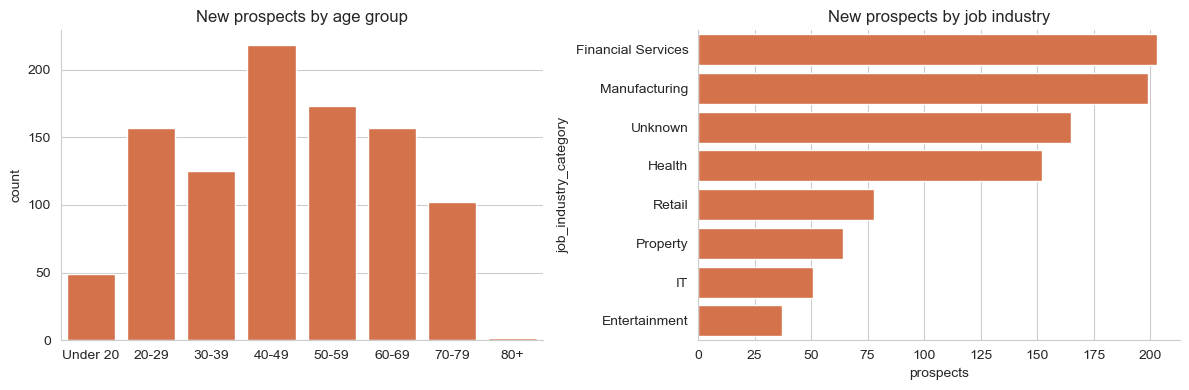

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

order = [l for l in labels if l in df['Age Group'].dropna().unique()]
sns.countplot(data=df, x='Age Group', order=order, color='#eb6834', ax=axes[0])
axes[0].set_title('New prospects by age group')
axes[0].set_xlabel('')

top = df['job_industry_category'].value_counts().head(8)
sns.barplot(x=top.values, y=top.index, color='#eb6834', ax=axes[1])
axes[1].set_title('New prospects by job industry')
axes[1].set_xlabel('prospects')

sns.despine()
plt.tight_layout()
plt.show()

## 8. Cleaned output

In [15]:
print(f'{len(df):,} rows x {df.shape[1]} columns')
df.head()

1,000 rows x 20 columns


,first_name,last_name,gender,past_3_years_bike_related_purchases,DOB,job_title,job_industry_category,wealth_segment,deceased_indicator,owns_car,tenure,address,postcode,state,country,property_valuation,Rank,Value,Age,Age Group
0,Chickie,Brister,Male,86,1957-07-12,General Manager,Manufacturing,Mass Customer,N,Yes,14,45 Shopko Center,4500,QLD,Australia,6,1,1.718750,60,60-69
1,Morly,Genery,Male,69,1970-03-22,Structural Engineer,Property,Mass Customer,N,No,16,14 Mccormick Park,2113,NSW,Australia,11,1,1.718750,48,40-49
2,Ardelis,Forrester,Female,10,1974-08-28,Senior Cost Accountant,Financial Services,Affluent Customer,N,No,10,5 Colorado Crossing,3505,VIC,Australia,5,1,1.718750,43,40-49
3,Lucine,Stutt,Female,64,1979-01-28,Account Representative III,Manufacturing,Affluent Customer,N,Yes,5,207 Annamark Plaza,4814,QLD,Australia,1,4,1.703125,39,30-39
4,Melinda,Hadlee,Female,34,1965-09-21,Financial Analyst,Financial Services,Affluent Customer,N,No,19,115 Montana Place,2093,NSW,Australia,9,4,1.703125,52,50-59


In [16]:
df.to_csv('NewCustomerList_Cleaned.csv', index=False)
print('saved NewCustomerList_Cleaned.csv')

saved NewCustomerList_Cleaned.csv


## Summary of changes

| # | Issue | Action | Records affected |
|---|---|---|---|
| 1 | Five unnamed columns holding intermediate arithmetic | dropped | all |
| 2 | Gender recorded inconsistently | standardised to Female / Male / Unknown | 17 |
| 3 | No age field | derived `Age` and `Age Group` as at 2017-12-31 | all |
| 4 | `job_title` and `job_industry_category` missing | filled `Unknown` | 271 |

**Kept but not trusted:** `Rank` and `Value` arrived with the file. `Value` is the output of
the formula whose workings were in the five unnamed columns, and no method is documented. They
are retained only so this project's own prospect scoring can be compared against them.

**Nothing removed.** Unlike the existing-customer table there was no age outlier and no
deceased record, so all 1,000 prospects survive.

**Cleaned to match:** every treatment mirrors the existing-customer notebook, because the two
tables are compared chart-for-chart in the EDA. Cleaning them differently would make the
comparison measure our own choices rather than the customers.